# Kaggle S6E3 — Telco Customer Churn: Exploration

> **This is the first public notebook built with [ml-labs](https://github.com/sunkusun9/ml-labs)** — a lightweight ML experiment management framework I've been developing.
> 
> ml-labs provides a declarative pipeline graph, experiment state management, LRU caching, and a unified collector system — letting you focus on analysis rather than plumbing.
>
> - **GitHub**: https://github.com/sunkusun9/ml-labs
> - **Docs**: https://sunkusun9.github.io/ml-labs/
>
> I know it's far from perfect. I'd appreciate your patience and understanding — any feedback or suggestions are warmly welcome!
---

## Notebook Overview

This notebook covers the **exploratory data analysis and ML pilot** for the [Kaggle Playground Series S6E3](https://www.kaggle.com/competitions/playground-series-s6e3) competition (Customer Churn prediction).

The key questions we explore:

1. **Train/Test distribution shift** — is the test set drawn from the same distribution?
2. **Categorical feature analysis** — information gain, mutual information between features
3. **Numerical feature analysis** — distributions, correlation, derived features
4. **ML pilot** — baseline performance across XGBoost, LightGBM, CatBoost, Logistic Regression, Decision Tree, and Neural Network
5. **Feature engineering pilot** — does treating `MonthlyCharges` as categorical help?

Full modeling and cross-validation follow in the next notebook.

In [1]:
import os
from pathlib import Path

import pandas as pd
import polars as pl
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import scipy
import sklearn
import tensorflow as tf
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import shap

import mllabs  # ml-labs: our experiment management framework

import sys
print(sys.version)

for i in [pd, pl, np, plt, sns, scipy, sklearn, tf, xgb, lgb, cb, mllabs, shap]:
    if hasattr(i, '__version__'):
        print(i.__name__, i.__version__)
    else:
        print(i.__name__)

2026-03-07 16:42:49.445017: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-07 16:42:49.783152: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-07 16:42:51.001002: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/sun9sun9/python312/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: Fu

3.12.12 (main, Dec 27 2025, 11:08:36) [GCC 13.3.0]
pandas 2.3.3
polars 1.38.1
numpy 2.3.5
matplotlib.pyplot
seaborn 0.13.2
scipy 1.16.3
sklearn 1.8.0
tensorflow 2.20.0
xgboost 3.2.0
lightgbm
catboost 1.2.8
mllabs 0.6.1
shap 0.50.0


In [2]:
from IPython.display import Markdown

from mllabs import Connector, Experimenter
from mllabs.collector import MetricCollector, ModelAttrCollector
from mllabs.adapter import LightGBMAdapter

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedShuffleSplit

from scipy.stats import mannwhitneyu, kruskal, spearmanr

In [3]:
from mllabs.processor import PolarsLoader, PandasConverter, ExprProcessor
from sklearn.pipeline import make_pipeline

data_path = Path('data')

# Binary-encode several categorical features using Polars expressions.
# We also derive indicator columns for internet-service-related features
# ('No internet service' is treated as a separate binary flag).
dict_expr = {
    'gender': (pl.col('gender') == 'Male').cast(pl.Int8),
    'No_Internet': (pl.col('DeviceProtection') == 'No internet service').cast(pl.Int8),
    'DSL_Y': (pl.col('InternetService') == 'DSL').cast(pl.Int8)
}
for i in ['Dependents', 'PaperlessBilling', 'Partner', 'PhoneService']:
    dict_expr[i] = (pl.col(i) == 'Yes').cast(pl.Int8)

for i in ['DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'StreamingMovies', 'StreamingTV', 'TechSupport', 'MultipleLines']:
    dict_expr[i + '_Y'] = (pl.col(i) == 'Yes').cast(pl.Int8)

# PolarsLoader reads CSVs into Polars DataFrames.
# ExprProcessor applies the expression dict above in a single vectorized pass.
# PandasConverter converts to pandas, setting 'id' as the index.
loader = make_pipeline(
    PolarsLoader(predefined_types={'id': pl.Int64}),
    ExprProcessor(dict_expr=dict_expr),
    PandasConverter(index_col='id')
)

df_train = loader.fit_transform([data_path / 'train.csv']).assign(
    Churn=lambda x: (x['Churn'] == 'Yes').astype('int8')
)
df_test = loader.transform([data_path / 'test.csv'])

In [4]:
# Variable groupings
# X_bin  : original binary features (Yes/No encoded as 0/1)
# X_tri  : 3-level categorical features (Yes / No / No internet service)
# X_bin2 : derived binary flags from X_tri (e.g. OnlineSecurity_Y)
# X_num  : numerical features
# X_nom  : nominal categoricals kept as strings for tree-based models
X_bin = ['Dependents', 'PaperlessBilling', 'Partner', 'PhoneService', 'gender', 'SeniorCitizen']
X_tri = ['DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'StreamingMovies', 'StreamingTV', 'TechSupport']
X_bin2 = ['{}_Y'.format(i) for i in X_tri] + ['No_Internet', 'DSL_Y', 'MultipleLines_Y']
X_tri.append('InternetService')
X_tri.append('MultipleLines')
X_num = ['TotalCharges', 'MonthlyCharges', 'tenure']
X_nom = ['PaymentMethod', 'Contract']
X_all = X_bin + X_tri + X_bin2 + X_num + X_nom

target = 'Churn'

# Train / Test Distribution Check

Before diving into the target, we first check whether the train and test sets follow the same feature distribution.
We train a classifier to distinguish train (label=0) from test (label=1).
A near-random AUC (~0.5) means no meaningful shift; a high AUC signals distribution drift that needs attention.

In [5]:
df_is_test = pd.concat([
    df_train[X_all].assign(is_test = 0),
    df_test[X_all].assign(is_test = 1)
])
df_is_test['is_test'].value_counts().pipe(
    lambda x: pd.concat([x, (x / x.sum()).rename('ratio')], axis=1)
)

,count,ratio
is_test,,
0,594194,0.7
1,254655,0.3


In [6]:
# ml-labs Experimenter: manages the experiment lifecycle (data split, caching, state persistence).
# Here we create a single hold-out split stratified on 'is_test'.
# Once created, it can be reloaded from disk — no need to re-run from scratch.
if os.path.exists('exp/is_test'):
    e_is_test = Experimenter.load('exp/is_test', df_is_test)
    if e_is_test.status == 'closed':
        e_is_test.reopen_exp()
else:
    e_is_test = Experimenter.create(
        df_is_test, 'exp/is_test', title='Train/Test discriminator',
        sp=StratifiedShuffleSplit(n_splits=1, random_state=1),
        sp_v=StratifiedShuffleSplit(n_splits=1, train_size=0.1, random_state=1),
        splitter_params={'y': 'is_test'}
    )
Markdown(
    e_is_test.desc_spec()
)

📁 Created directory: exp/is_test


## Train/Test discriminator

| 항목 | 값 |
|------|-----|
| **Outer Splitter (sp)** | `StratifiedShuffleSplit(n_splits=1, random_state=1)` |
| **Inner Splitter (sp_v)** | `StratifiedShuffleSplit(n_splits=1, random_state=1)` |
| **Splitter Params** | `{y='is_test'}` |
| **Outer Folds** | 1 |
| **Inner Folds** | 1 |

In [7]:
# Register collectors before running experiments.
# MetricCollector computes AUC on the validation fold after each node finishes.
# ModelAttrCollector extracts feature_importances from any LGBMClassifier node.
e_is_test.add_collector(
    MetricCollector(
        'AUC', Connector(edges={'y': [(None, 'is_test')]}), slice(-1, None), roc_auc_score, include_train=True
    )
)
e_is_test.add_collector(
    ModelAttrCollector(
        'lgb_feature_importance', Connector(processor=lgb.LGBMClassifier), 'feature_importances'
    )
)

# Pipeline: a single head group using predict_proba, trained on all features
e_is_test.set_grp('clf', role='head', edges={'y': [(None, 'is_test')]}, method='predict_proba')

# lgb1: default LightGBM with native categorical support
e_is_test.set_node(
    'lgb1', grp='clf', processor=lgb.LGBMClassifier, edges={'X': [(None, X_all)]},
    params={'verbose': -1, 'categorical_features': X_nom}
)

Collect 1/1 (100%)       
Collect 1/1 (100%)       


{'result': 'new',
 'affected_nodes': [],
 'old_obj': None,
 'obj': <mllabs._pipeline.PipelineNode at 0x742b172f7200>}

In [8]:
e_is_test.exp()

Experimenting 1 node(s)
Exp 1/1 (100%)                                                                                              
Experimentation complete: 1 node(s)


In [9]:
e_is_test.get_collector('AUC').get_metrics_agg()[0]

,valid,train_sub,valid_sub
lgb1,0.509518,0.650932,0.510088


In [10]:
# lgb2: same model but with early stopping using a validation set.
# Note: 'early_stopping' is now passed as a dict — ml-labs LightGBMAdapter
# constructs the lgb_early_stopping callback internally, which also avoids
# false param-change detection in the pipeline diff engine.
e_is_test.set_node(
    'lgb2', grp='clf', processor=lgb.LGBMClassifier, edges={'X': [(None, X_all)]},
    adapter=LightGBMAdapter(eval_mode='valid'),
    params={
        'verbose': -1, 'categorical_features': X_nom,
        'early_stopping': {'stopping_rounds': 50, 'first_metric_only': True},
        'n_estimators': 5000
    }
)
e_is_test.exp()

Experimenting 1 node(s)
Exp 0/1 (0%) > lgb2 0/1 (0%) > 1/5000 (0%) valid_0-binary_logloss: 0.6107Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[15]	valid_0's binary_logloss: 0.610147
Evaluated only: binary_logloss
Exp 1/1 (100%)                                                           
Experimentation complete: 1 node(s)


In [11]:
e_is_test.get_collector('AUC').get_metrics_agg()[0]

,valid,train_sub,valid_sub
lgb1,0.509518,0.650932,0.510088
lgb2,0.506674,0.549849,0.510162


**Conclusion**: The classifier shows near-random AUC (~0.5), meaning the model cannot distinguish train from test samples.
There is no meaningful distribution shift — the test set can be treated as drawn from the same population as train.

In [12]:
e_is_test.close_exp()

Finalize 'lgb1'
Finalize 'lgb2'


# Target: Churn

Let's look at the class distribution of the target variable.

In [13]:
df_train[target].value_counts().pipe(
    lambda x: pd.concat([x, (x / x.sum()).rename('ratio')], axis=1)
)

,count,ratio
Churn,,
0,460377,0.774792
1,133817,0.225208


# Categorical Variables

We analyze which categorical features are most predictive of churn using **information gain** and **mutual information between features**.

## Information gain

In [14]:
# Information Gain = H(target) - H(target | feature)
# Higher IG → the feature carries more information about churn.
# We compute the entropy of the target first, then subtract the conditional entropy for each feature.
y_prob = df_train[target].value_counts(normalize=True)
H_target = -y_prob.dot(np.log(y_prob))

pd.Series({
    i: H_target - pd.crosstab(index=df_train[i], columns=df_train[target], normalize='index').apply(
        lambda x: -x.dot(np.log(x)), axis=1
    ).dot(df_train[i].value_counts(normalize=True)) for i in X_bin + X_tri + X_bin2 + X_nom
}, name='IG').sort_values(ascending=False)

Contract              0.133328
PaymentMethod         0.112203
OnlineSecurity        0.105165
InternetService       0.103407
TechSupport           0.100455
OnlineBackup          0.079472
DeviceProtection      0.074180
StreamingMovies       0.055795
StreamingTV           0.055749
No_Internet           0.055674
PaperlessBilling      0.045913
Dependents            0.033733
Partner               0.026463
OnlineSecurity_Y      0.024069
SeniorCitizen         0.023878
DSL_Y                 0.020890
TechSupport_Y         0.020675
StreamingTV_Y         0.006786
MultipleLines         0.006633
MultipleLines_Y       0.006596
StreamingMovies_Y     0.006481
OnlineBackup_Y        0.005195
DeviceProtection_Y    0.002823
PhoneService          0.000647
gender                0.000023
Name: IG, dtype: float64

**My take**: `Contract` and `PaymentMethod` clearly dominate the IG ranking — both capturing billing behavior closely tied to churn intent.
The binary `_Y` flags derived from the tri-level features rank lower than their originals, suggesting the original 3-level encoding carries more nuance worth preserving for tree-based models.
Notably, `gender` and `Dependents` are near the bottom — largely uninformative for this task.

How well can just `Contract` and `PaymentMethod` predict churn on their own?
Let's use group mean as a simple probability estimate and measure AUC.

In [15]:
roc_auc_score(
    df_train[target], df_train.groupby('Contract', observed=True)[target].transform('mean')
)

0.7894150683901222

In [16]:
roc_auc_score(
    df_train[target], df_train.groupby('PaymentMethod', observed=True)[target].transform('mean')
)

0.776768714041246

## Correlation

In [17]:
# Mutual Information between categorical feature pairs.
# MI(X, Y) = H(X) - H(X | Y): measures how much knowing Y reduces uncertainty about X.
# High MI between two features signals redundancy — tree models may not benefit from both.
X_val = X_bin + X_bin2 + X_nom
ig_list = []
for j in X_val[:-1]:
    prob = df_train[j].value_counts(normalize=True)
    H = -prob.dot(np.log(prob))
    ig_list.append(
        pd.Series({
            i: H - pd.crosstab(index=df_train[i], columns=df_train[j], normalize='index').apply(
                lambda x: -x.dot(np.log(x + 1e-10)), axis=1
            ).dot(df_train[i].value_counts(normalize=True)) for i in X_val if i > j
        }, name=j).to_frame().unstack().rename('MI').reset_index().rename(columns={'level_0': 'value_1', 'level_1': 'value_2'})
    )

In [18]:
pd.concat(ig_list).sort_values('MI', ascending = False).iloc[:30]

,value_1,value_2,MI
1,StreamingMovies_Y,StreamingTV_Y,0.228824
1,Dependents,Partner,0.162079
7,No_Internet,StreamingMovies_Y,0.148113
8,No_Internet,StreamingTV_Y,0.147144
10,No_Internet,PaymentMethod,0.122630
10,DeviceProtection_Y,No_Internet,0.119651
5,No_Internet,OnlineBackup_Y,0.117609
7,DeviceProtection_Y,StreamingMovies_Y,0.111997
8,DeviceProtection_Y,StreamingTV_Y,0.111674
0,No_Internet,PaperlessBilling,0.108854


In [19]:
df_train.pivot_table(index = 'StreamingMovies_Y', columns = 'StreamingTV_Y', aggfunc = 'size', observed = True)

StreamingTV_Y,0,1
StreamingMovies_Y,,
0,303920,48839
1,49973,191462


`Contract` and `PaymentMethod` are nearly independent (low MI), so combining them is expected to add predictive power.

In [20]:
roc_auc_score(
    df_train[target], df_train.groupby(['Contract', 'PaymentMethod'], observed=True)[target].transform('mean')
)

0.8549348614717375

Adding `OnlineSecurity` as a third grouping key:

In [21]:
roc_auc_score(
    df_train[target], df_train.groupby(['Contract', 'PaymentMethod', 'OnlineSecurity'], observed=True)[target].transform('mean')
)

0.8694661817805394

**My take**: Just three categorical features — `Contract`, `PaymentMethod`, `OnlineSecurity` — give a strong AUC signal with zero numerical data.
This confirms that contractual and service-bundle choices are the primary drivers of churn in this dataset.
The remaining features will likely provide incremental rather than dramatic gains.

# Numerical Variables

We examine the three numerical features: `TotalCharges`, `MonthlyCharges`, and `tenure`.

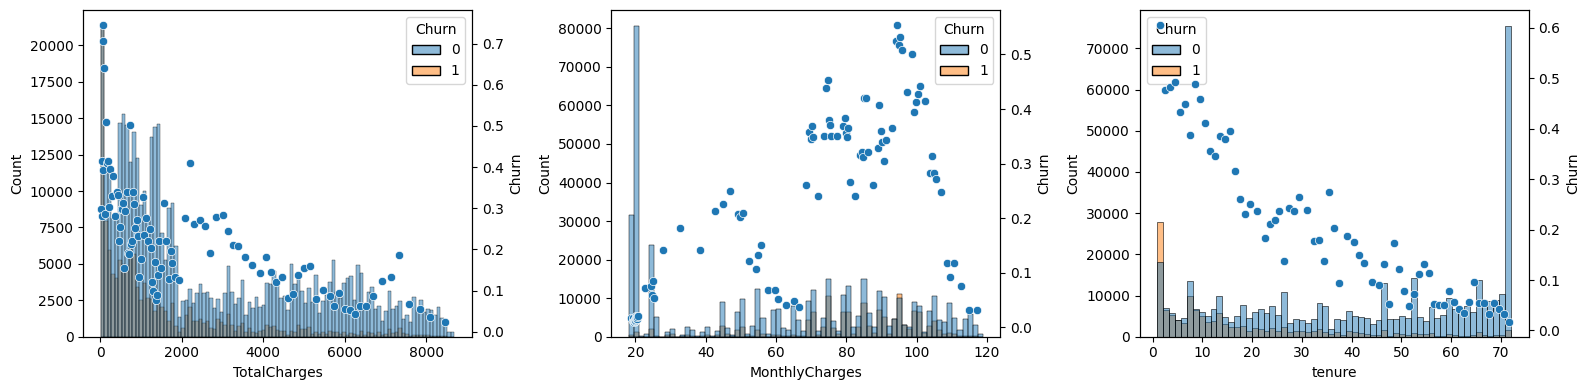

In [22]:
# Distribution by churn label (histogram) + churn rate by quantile (scatter on twin axis).
# The scatter overlaid on the histogram gives an intuitive view of how churn probability
# changes across the value range of each numerical feature.
_, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, ax in zip(X_num, axes.flatten()):
    sns.histplot(df_train, x=i, ax=ax, hue=target)
    df_train.groupby(pd.qcut(df_train[i], q=100, duplicates='drop'), observed=True)[target].mean().reset_index().assign(
        q_median=lambda x: (x[i].cat.categories.left + x[i].cat.categories.right) / 2
    ).pipe(
        lambda x: sns.scatterplot(x, x='q_median', y=target, ax=ax.twinx())
    )
plt.tight_layout()
plt.show()

In [23]:
roc_auc_score(df_train[target], -df_train['tenure'])

0.7936764118576458

In [24]:
roc_auc_score(df_train[target], df_train['MonthlyCharges'])

0.6790063142581958

In [25]:
roc_auc_score(df_train[target], -df_train['TotalCharges'])

0.6678535948669334

In [26]:
df_train[X_num].corr().unstack().rename('corr').reset_index().query('level_0 < level_1')

,level_0,level_1,corr
2,TotalCharges,tenure,0.769703
3,MonthlyCharges,TotalCharges,0.634237
5,MonthlyCharges,tenure,0.124043


In [27]:
# Sanity check: for customers with tenure==1, MonthlyCharges should equal TotalCharges.
# If so, TotalCharges ≈ MonthlyCharges * tenure — and the ratio might be a stable derived feature.
df_train.query('tenure == 1').pipe(
    lambda x: x['MonthlyCharges'] - x['TotalCharges']
).value_counts(normalize=True)

 0.000000      0.911281
-1.000000      0.022685
 1.000000      0.016894
-2.000000      0.004797
 2.000000      0.003290
                 ...   
-422.750000    0.000034
 5.400002      0.000034
 30.199999     0.000034
-75.199997     0.000034
 30.750000     0.000034
Name: proportion, Length: 418, dtype: float64

In [28]:
roc_auc_score(df_train[target], df_train['MonthlyCharges'] / df_train['tenure'])

0.8557175787629429

In [29]:
roc_auc_score(df_train[target], df_train['TotalCharges'] / df_train['tenure'])

0.6834943642074567

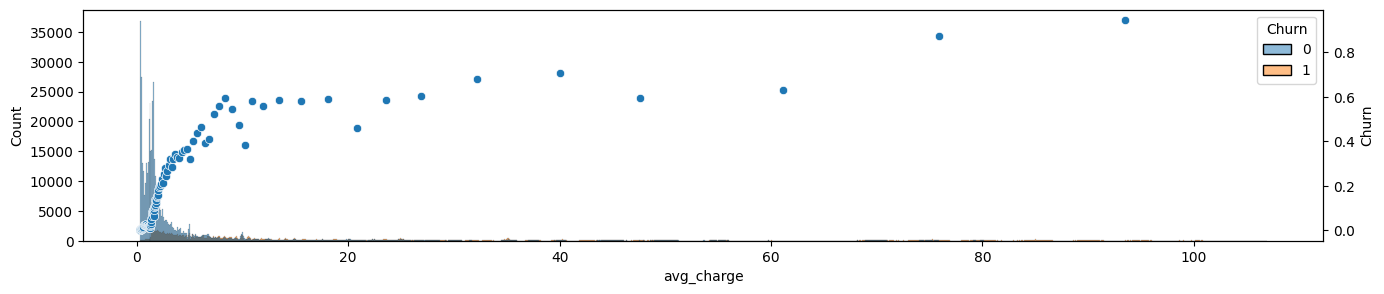

In [30]:
plt.figure(figsize=(16, 3))
ax = plt.gca()
avg_charge = (df_train['MonthlyCharges'] / df_train['tenure']).rename('avg_charge')
sns.histplot(x=avg_charge, ax = ax, hue = df_train[target])
df_train.groupby(pd.qcut(avg_charge, q = 100, duplicates = 'drop'), observed = True)[target].mean().reset_index().assign(
    q_median = lambda x: (x['avg_charge'].cat.categories.left + x['avg_charge'].cat.categories.right) / 2
).pipe(
    lambda x: sns.scatterplot(x, x = 'q_median', y = target, ax = ax.twinx())
)
plt.show()

Could `MonthlyCharges` represent a **rate plan tier** rather than a smoothly continuous value?
The value count below will tell us if charges are clustered at discrete levels.

In [31]:
df_train['MonthlyCharges'].value_counts()

MonthlyCharges
20.049999    7436
19.950001    5718
19.700001    5705
20.000000    5493
19.850000    5114
             ... 
32.450001       1
31.299999       1
89.239998       1
21.700001       1
46.150002       1
Name: count, Length: 1921, dtype: int64

In [32]:
roc_auc_score(
    df_train[target], df_train.groupby('MonthlyCharges')[target].transform('mean')
)

0.779535041604032

In [33]:
from sklearn.preprocessing import TargetEncoder

tgt = TargetEncoder()
roc_auc_score(
    df_train[target], tgt.fit_transform(df_train[['MonthlyCharges']], df_train[target])[:, 0]
)

0.7749452437141664

**Observation**: `MonthlyCharges` appears to have many near-discrete values, which makes treating it as a categorical worth trying.
However, some values appear rarely — OOV (out-of-vocabulary) handling will be important if we go that route.

# ML Pilot & Analysis

We run a quick pilot across multiple model families to:
- Get a baseline sense of problem difficulty
- Understand which models converge well with default settings
- Identify which features matter (via importance, SHAP, coefficients, and interaction scores)

Models compared: **XGBoost**, **LightGBM**, **CatBoost**, **Decision Tree**, **Logistic Regression**, **Neural Network (ml-labs NNClassifier)**

In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from mllabs.nn import NNClassifier
from mllabs import ColSelector
from mllabs.adapter import XGBoostAdapter, LightGBMAdapter, CatBoostAdapter
from mllabs.collector import SHAPCollector
from mllabs.filter import RandomFilter
from mllabs.col import ohe_drop_first

In [35]:
# Derived feature: average monthly charge over the customer's lifetime.
# TotalCharges / tenure ≈ average monthly spend, which may differ from the current MonthlyCharges.
df_train['mt_ratio'] = df_train['TotalCharges'] / df_train['tenure']
X_num = X_num[:3]  # reset to base 3 (idempotent on re-run)
X_num.append('mt_ratio')

## Experiment Setup

We use `Experimenter.create` to set up a hold-out experiment with a stratified split.
The inner validation fold (`sp_v`) is used for early stopping in gradient boosting models.

In [36]:
if os.path.exists('exp/analysis'):
    e_aml = Experimenter.load('exp/analysis', df_train)
    if e_aml.status == 'closed':
        e_aml.reopen_exp()
else:
    e_aml = Experimenter.create(
        df_train, 'exp/analysis', title='The experimentation for ML Pilot & Analysis',
        sp=StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=1),
        sp_v=StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=1),
        splitter_params={'y': target}
    )
Markdown(
    e_aml.desc_spec()
)

📁 Created directory: exp/analysis


## 파일럿과 데이터 탐색을 위한 ML 실험

| 항목 | 값 |
|------|-----|
| **Outer Splitter (sp)** | `StratifiedShuffleSplit(n_splits=1, random_state=1, test_size=0.3)` |
| **Inner Splitter (sp_v)** | `StratifiedShuffleSplit(n_splits=1, random_state=1, test_size=0.1)` |
| **Splitter Params** | `{y='Churn'}` |
| **Outer Folds** | 1 |
| **Inner Folds** | 1 |

In [47]:
# Pipeline setup
# ml-labs uses a node graph: Stage nodes (preprocessing) → Head nodes (models).
# set_grp defines a group template; set_node creates individual experiment nodes.

e_aml.set_grp('pre', role='stage', method='transform')
y_edges = {'y': [(None, target)]}
e_aml.set_grp(
    'clf', role='head', method='predict_proba', edges=y_edges
)

# XGBoost — uses XGBoostAdapter to pass eval_set and early_stopping_rounds
e_aml.set_grp('xgb', parent='clf', processor=xgb.XGBClassifier,
    adapter=XGBoostAdapter(eval_mode='both'),
    params={
        'n_estimators': 10000, 'learning_rate': 0.05, 'early_stopping_rounds': 50,
        'eval_metric': 'auc', 'enable_categorical': True,
        'verbosity': 0, 'random_state': 1,
    }
)
e_aml.add_collector(
    ModelAttrCollector('xgb_evals_results', Connector(processor=xgb.XGBClassifier), 'evals_result')
)

# LightGBM — early_stopping passed as dict; LightGBMAdapter creates the callback internally
e_aml.set_grp('lgb', parent='clf', processor=lgb.LGBMClassifier,
    adapter=LightGBMAdapter(eval_mode='both'),
    params={
        'n_estimators': 10000, 'learning_rate': 0.05,
        'early_stopping': {'stopping_rounds': 50, 'first_metric_only': True},
        'eval_metric': 'auc', 'verbose': -1, 'random_state': 1,
    }
)
e_aml.add_collector(
    ModelAttrCollector('lgb_evals_results', Connector(processor=lgb.LGBMClassifier), 'evals_result')
)

# CatBoost — CatBoostAdapter handles cat_features and eval_set
e_aml.set_grp('cb', parent='clf', processor=cb.CatBoostClassifier,
    adapter=CatBoostAdapter(eval_mode='both'),
    params={
        'iterations': 10000, 'learning_rate': 0.05, 'early_stopping_rounds': 50,
        'eval_metric': 'AUC', 'verbose': 0, 'random_state': 1,
    }
)
e_aml.add_collector(
    ModelAttrCollector('cb_evals_results', Connector('_base$', processor=cb.CatBoostClassifier), 'evals_result')
)

# LogisticRegression
e_aml.set_grp('lr', parent='clf', processor=LogisticRegression,
    params={
        'max_iter': 1000, 'random_state': 1,
    }
)

# DecisionTreeClassifier for plot tree
e_aml.set_grp('dt', parent='clf', processor=DecisionTreeClassifier,
    params={
        'max_depth': 4, 'random_state': 1,
    }
)

## Neural network
e_aml.set_grp('nn', parent = 'clf', processor = NNClassifier, params = {'metrics': ['auc'], 'early_stopping': 10})
e_aml.add_collector(
    ModelAttrCollector('nn_evals', Connector(processor=NNClassifier), result_key='evals_result')
)

In [48]:
# Collector 구성

e_aml.add_collector(
    MetricCollector(
        'AUC',
        Connector(edges=y_edges), slice(-1, None), roc_auc_score, include_train = True
    )
)

# Feature importance — LGB
e_aml.add_collector(
    ModelAttrCollector(
        'lgb_feature_importance',
        Connector(processor=lgb.LGBMClassifier, edges=y_edges),
        'feature_importances'
    )
)

# Feature importance — XGB
e_aml.add_collector(
    ModelAttrCollector(
        'xgb_feature_importance_gain',
        Connector(processor=xgb.XGBClassifier, edges=y_edges),
        'feature_importances', params = {'importance_type': 'gain'}
    )
)

e_aml.add_collector(
    ModelAttrCollector(
        'xgb_feature_importance_cover',
        Connector(processor=xgb.XGBClassifier, edges=y_edges),
        'feature_importances', params = {'importance_type': 'cover'}
    )
)

# CatBoost feature importance (PredictionValuesChange)
e_aml.add_collector(
    ModelAttrCollector(
        'cb_feature_importance',
        Connector(processor=cb.CatBoostClassifier, edges=y_edges),
        'feature_importances_pvc'
    )
)

# CatBoost feature interaction importance
e_aml.add_collector(
    ModelAttrCollector(
        'cb_interaction',
        Connector(processor=cb.CatBoostClassifier, edges=y_edges),
        'feature_importances_interaction'
    )
)

# LogisticRegression coef
e_aml.add_collector(
    ModelAttrCollector(
        'lr_coef',
        Connector(processor=LogisticRegression, edges=y_edges),
        'coef'
    )
)

In [49]:
set(df_train.columns) - set(X_bin + X_nom + X_tri + X_num)

{'Churn',
 'DSL_Y',
 'DeviceProtection_Y',
 'MultipleLines_Y',
 'No_Internet',
 'OnlineBackup_Y',
 'OnlineSecurity_Y',
 'StreamingMovies_Y',
 'StreamingTV_Y',
 'TechSupport_Y'}

## Run Experiments

In [50]:
# Stage nodes: OHE for nominal categoricals, StandardScaler for numerics.
# build() fits and caches all stage nodes — head nodes will draw from these cached outputs.
e_aml.set_node('ohe', processor=OneHotEncoder, grp='pre', edges={'X': [(None, X_nom)]}, params={'sparse_output': False})
e_aml.set_node('std', processor=StandardScaler, grp='pre', edges={'X': [(None, X_num)]})
e_aml.build()

Building 0 node(s)
Build 1/1 (100%)       
Build complete: 0 node(s)


In [51]:
# Define one baseline node per model family.
# Tree models receive raw categorical columns; sklearn models get OHE/scaled inputs.
# ColSelector(col_type='category') dynamically selects categorical columns at fit time.
e_aml.set_node('xgb_base', grp='xgb', edges={'X': [(None, X_bin + X_nom + X_tri + X_num)]})
e_aml.set_node('lgb_base', grp='lgb', edges={'X': [(None, X_bin + X_nom + X_tri + X_num)]}, params={'categorical_features': ColSelector(col_type='category')})
e_aml.set_node('cb_base', grp='cb', edges={'X': [(None, X_bin + X_nom + X_tri + X_num)]}, params={'cat_features': ColSelector(col_type='category')})
e_aml.set_node('dt_base', grp='dt', edges={'X': [(None, X_bin + X_bin2 + X_num), ('ohe', None)]})
e_aml.set_node('lr_base', grp='lr', edges={'X': [(None, X_bin + X_bin2), ('std', None), ('ohe', ohe_drop_first)]})
e_aml.set_node('nn_base', grp='nn', edges={'X': [(None, X_bin + X_nom + X_bin2), ('std', None)]})
e_aml.exp()

Experimenting 6 node(s)
Exp 0/1 (0%) > lgb_base 2/6 (33%) > 1/10000 (0%) valid_0-auc: 0.9029, valid_0-binary_logloss: 0.5130, valid_1-auc: 0.9030, valid_1-binary_logloss: 0.5129Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[655]	valid_0's auc: 0.924048	valid_0's binary_logloss: 0.285082	valid_1's auc: 0.917028	valid_1's binary_logloss: 0.2971
Evaluated only: auc
Exp 0/1 (0%) > nn_base 3/6 (50%)                                                                                                                         

I0000 00:00:1772869699.780621   33690 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5518 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Exp 1/1 (100%)                                                                                              
Experimentation complete: 6 node(s)


## Results Analysis

### Training Time (seconds)

In [52]:
# get_objs(node, fold_idx) returns a generator of (processor, result, info) tuples.
# info['fit_time'] is recorded by ml-labs during the experiment run.
pd.Series({
    i: next(e_aml.get_objs(i, 0))[2]['fit_time']
    for i in ['xgb_base', 'lgb_base', 'cb_base', 'dt_base', 'lr_base', 'nn_base']
}).sort_values(ascending=False)

nn_base     153.303461
cb_base     130.171165
lgb_base     12.976671
xgb_base      8.301918
lr_base       2.517444
dt_base       0.522936
dtype: float64

CatBoost takes long — let's see if GPU mode helps.

Let's try CatBoost with GPU acceleration.

In [53]:
e_aml.set_node('cb_base_gpu', grp='cb', processor=cb.CatBoostClassifier,
    adapter=CatBoostAdapter(eval_mode='eval'), # Using CatBoost, In case of usiing GP, Only eval set is available
    edges = {'X': [(None, X_bin + X_nom + X_tri + X_num)]}, params={'task_type': 'GPU', 'cat_features': ColSelector(col_type = 'category')}
)
e_aml.exp()

Experimenting 1 node(s)
Exp 0/1 (0%) > cb_base_gpu 0/1 (0%)

Default metric period is 5 because AUC is/are not implemented for GPU


Exp 1/1 (100%)                       
Experimentation complete: 1 node(s)


In [54]:
pd.Series({
    i: next(e_aml.get_objs(i, 0))[2]['fit_time']
    for i in ['xgb_base', 'lgb_base', 'cb_base', 'cb_base_gpu', 'dt_base', 'lr_base', 'nn_base']
}).sort_values(ascending = False)

cb_base_gpu    326.038532
nn_base        153.303461
cb_base        130.171165
lgb_base        12.976671
xgb_base         8.301918
lr_base          2.517444
dt_base          0.522936
dtype: float64

In [55]:
len(
    next(e_aml.get_objs('cb_base', 0))[0].obj.evals_result_['learn']['Logloss']
)

1072

In [56]:
len(
    next(e_aml.get_objs('cb_base_gpu', 0))[0].obj.evals_result_['learn']['Logloss']
)

2001

**Note**: CatBoost CPU and GPU implementations can behave quite differently even with default settings — including different early stopping points and scores.
In this run, GPU mode was actually slower and stopped at nearly double the iterations.
CatBoost's GPU behavior can also vary noticeably across versions — results may differ on your environment.

### AUC

Baseline performance with default params (only early stopping tuned). Take these numbers as directional — not final.

In [57]:
e_aml.get_collector('AUC').get_metrics_agg('.*_base$|._gpu$')[0].sort_values('valid', ascending = False)

,valid,train_sub,valid_sub
cb_base,0.915478,0.919196,0.916974
xgb_base,0.915396,0.924214,0.916982
lgb_base,0.915304,0.924048,0.917028
cb_base_gpu,0.913448,0.931443,0.914768
nn_base,0.912434,0.915343,0.914491
lr_base,0.907455,0.908050,0.908985
dt_base,0.894513,0.894691,0.895593


**My take**: All gradient boosting models cluster in a fairly narrow AUC band, suggesting the ceiling for this problem is set by the features rather than the algorithm.
LR's competitive performance further confirms that the signal is largely linear and categorical — a well-engineered feature set will matter more than architecture tuning here.

The GPU vs CPU performance gap in CatBoost is confirmed here — a consistent delta in AUC, not just noise.

### Plot tree

In [58]:
from sklearn.tree import plot_tree

In [59]:
# Access the fitted processor object from a specific node and fold.
# proc.obj is the raw sklearn estimator; proc.X_ contains the input column names used during fit.
proc = next(e_aml.get_objs('dt_base', 0))[0]
proc.obj, proc.X_[:3]

(DecisionTreeClassifier(max_depth=4, random_state=1),
 ['Dependents', 'PaperlessBilling', 'Partner'])

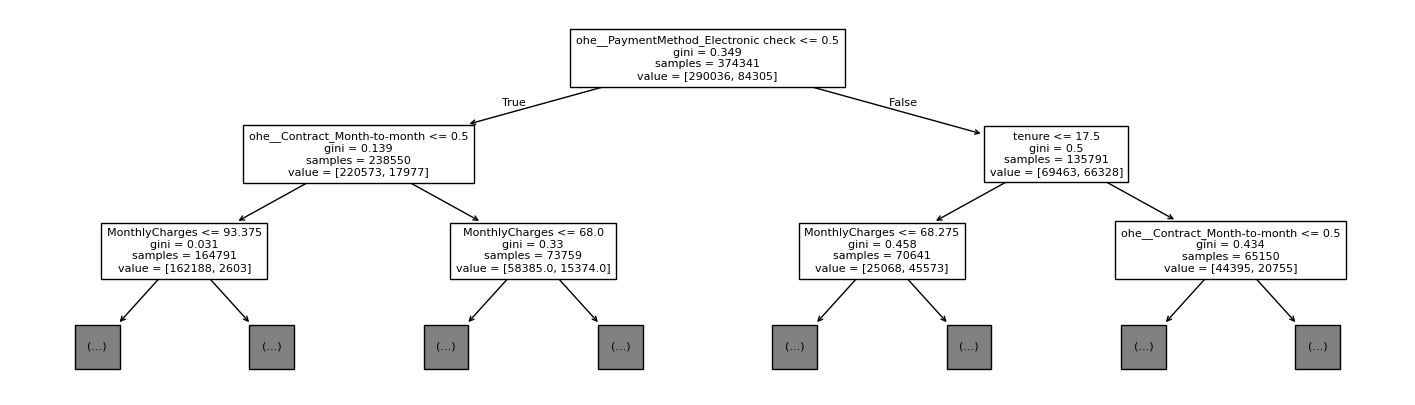

In [60]:
# Visualize the top 2 levels of the decision tree to understand the primary splits.
plt.figure(figsize=(18, 5))
plot_tree(
    proc.obj, max_depth=2, feature_names=proc.X_, fontsize=8
)
plt.show()

The tree's top splits confirm our EDA findings: `PaymentMethod`, `Contract`, `MonthlyCharges`, and `tenure` are the primary decision points.
Note: "PymentMethod" and "MonthlyChagrge" in the tree labels reflect the original column names — just typos in the feature name.

In [61]:
e_aml.set_node('lr_base2', grp='lr', edges = {'X': [('std', ['.*MonthlyCharges', '.*tenure']), ('ohe', ['cap', ohe_drop_first, '.*PymentMethod'])]})
e_aml.exp()

Experimenting 1 node(s)
Exp 1/1 (100%)                    
Experimentation complete: 1 node(s)


In [62]:
e_aml.get_obj_vars('lr_base2', 0)[0][0]

['std__MonthlyCharges',
 'std__tenure',
 'ohe__PaymentMethod_Credit card (automatic)',
 'ohe__PaymentMethod_Electronic check',
 'ohe__PaymentMethod_Mailed check',
 'ohe__Contract_One year',
 'ohe__Contract_Two year']

In [63]:
e_aml.get_collector('AUC').get_metrics_agg('lr.*')[0]

,valid,train_sub,valid_sub
lr_base,0.907455,0.908050,0.908985
lr_base2,0.898323,0.898298,0.900028


Just three features (`MonthlyCharges`, `tenure`, and `PaymentMethod`) yield AUC ~0.898 with Logistic Regression — a remarkably strong baseline for such a small feature set.

### Feature Importance

In [64]:
# SHAPCollector can be used ad-hoc (not pre-registered) via e_aml.collect().
# data_filter subsamples the validation set to keep SHAP computation fast.
shap_col = SHAPCollector(
    'shap',
    Connector(processor=xgb.XGBClassifier),
    data_filter=RandomFilter(frac=0.1, random_state=1)
)
e_aml.collect(shap_col)

Collect 1/1 (100%)                    


In [65]:
# Compare feature importances from multiple methods and models side by side.
# Each series is normalized to sum to 1 for fair comparison across methods.
pd.concat([
    e_aml.collectors['lgb_feature_importance'].get_attrs_agg('lgb_base').pipe(
        lambda x: x / x.sum()
    ).rename('lgb'),
    e_aml.collectors['xgb_feature_importance_gain'].get_attrs_agg('xgb_base').pipe(
        lambda x: x / x.sum()
    ).rename('xgb_gain'),
    e_aml.collectors['xgb_feature_importance_cover'].get_attrs_agg('xgb_base').pipe(
        lambda x: x / x.sum()
    ).rename('xgb_cover'),
    e_aml.collectors['cb_feature_importance'].get_attrs_agg('cb_base').pipe(
        lambda x: x / x.sum()
    ).rename('cb'),
    shap_col.get_feature_importance_agg('xgb_base').pipe(lambda x: x / x.sum()).rename('xgb_shap')
], axis=1).pipe(
    lambda x: x.iloc[np.argsort(-x.sum(axis=1))]
)

,lgb,xgb_gain,xgb_cover,cb,xgb_shap
Contract,0.032672,0.385472,0.082325,0.188048,0.312617
InternetService,0.008397,0.419611,0.120529,0.022696,0.096416
tenure,0.115420,0.025640,0.077315,0.217366,0.103449
MonthlyCharges,0.205089,0.002854,0.056219,0.128205,0.037335
TotalCharges,0.213893,0.003143,0.085846,0.068370,0.050460
mt_ratio,0.190789,0.004632,0.043186,0.107989,0.065113
PaymentMethod,0.022188,0.046912,0.024903,0.091013,0.082414
PaperlessBilling,0.020560,0.010944,0.051110,0.031844,0.036736
OnlineSecurity,0.017964,0.020336,0.032621,0.033491,0.044784
MultipleLines,0.021730,0.008458,0.053841,0.020506,0.033278


**My take**: `Contract` consistently tops the importance ranking across all models and methods — a strong signal.
However, the rankings diverge significantly below the top few features.
This divergence is partly explained by collinearity: boosting models spread credit across correlated features, so column subsampling (`colsample_bytree`) is likely to help.

### SHAP Analysis

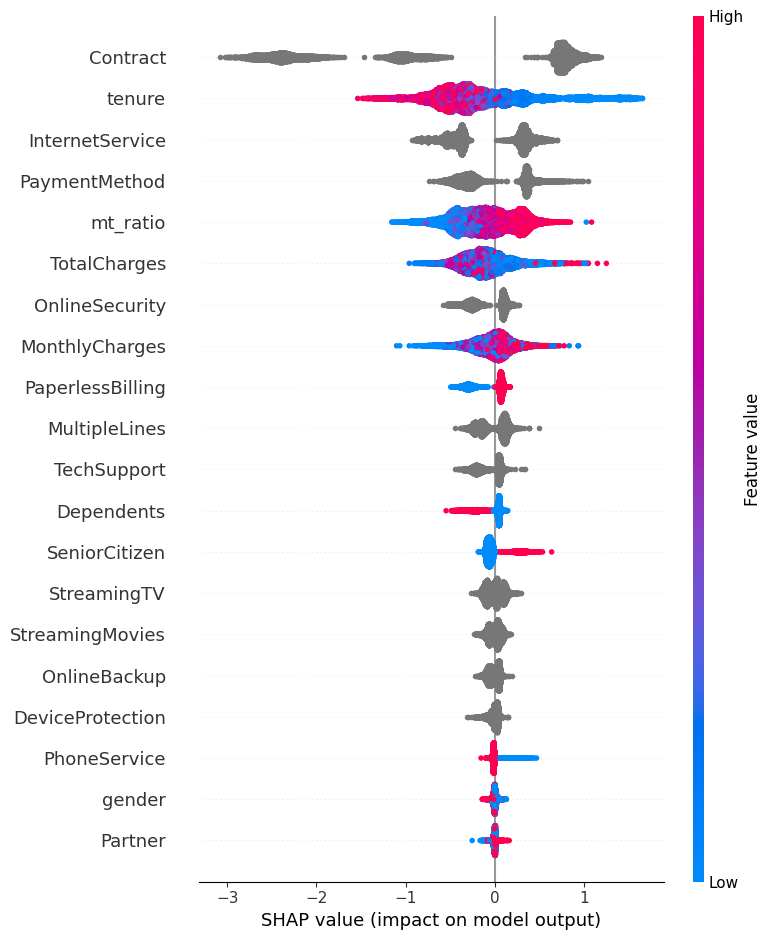

In [66]:
import shap
import matplotlib.pyplot as plt

# Load SHAP values collected for xgb_base, fold 0, inner fold 0.
shap_data = shap_col._load_node_data('xgb_base')
entry = shap_data[(0, 0)]
shap_values = entry['valid']
valid_index = entry['valid_index']
columns = entry['columns']

# Summary plot: each dot is a sample; color = feature value, x-axis = SHAP impact on prediction.
X_valid_shap = df_train.loc[valid_index, columns]
shap.summary_plot(shap_values, X_valid_shap, feature_names=columns, show=False)
plt.tight_layout()
plt.show()

**My take**: The SHAP summary gives cleaner directional insight than raw importances.
- Low `tenure` (short-term customers) strongly drives churn — customers haven't committed long enough to stay.
- High `MonthlyCharges` pushes toward churn — expensive plans with less perceived value lead to cancellation.
- `Contract` type dominates: month-to-month customers have much higher churn SHAP values than annual contracts.

The SHAP directions align well with business intuition, which increases confidence in the model.

### Interaction

In [67]:
e_aml.get_collector('cb_interaction').get_attrs_agg('cb_base').sort_values(ascending = False).iloc[:20]

feat1           feat2         
TotalCharges    MonthlyCharges    8.826865
                mt_ratio          6.595920
                tenure            5.824114
MonthlyCharges  mt_ratio          5.528428
                tenure            5.290089
tenure          mt_ratio          3.803151
Contract        TotalCharges      2.051496
                tenure            1.991427
PaymentMethod   TotalCharges      1.967826
                tenure            1.782574
Contract        MonthlyCharges    1.516064
PaymentMethod   MultipleLines     1.482609
OnlineBackup    TotalCharges      1.296361
MultipleLines   TotalCharges      1.290375
PaymentMethod   MonthlyCharges    1.241399
MultipleLines   tenure            1.216481
Contract        MultipleLines     1.193000
PaymentMethod   mt_ratio          1.191852
TechSupport     TotalCharges      1.165795
Contract        mt_ratio          1.031420
dtype: float64

### Coefficient of LR

In [68]:
e_aml.get_collector('lr_coef').get_attrs_agg('lr_base').pipe(
    lambda x: x.iloc[np.argsort(-x.abs())]
)

0  No_Internet                                  -2.057745
   std__tenure                                  -1.843806
   intercept                                    -1.583219
   ohe__Contract_Two year                       -1.394397
   DSL_Y                                        -0.991805
   std__TotalCharges                             0.826864
   ohe__Contract_One year                       -0.762044
   ohe__PaymentMethod_Electronic check           0.674031
   PhoneService                                 -0.515616
   SeniorCitizen                                 0.439797
   PaperlessBilling                              0.406255
   OnlineSecurity_Y                             -0.376698
   StreamingTV_Y                                 0.376153
   MultipleLines_Y                               0.352179
   StreamingMovies_Y                             0.337248
   Dependents                                   -0.333310
   TechSupport_Y                                -0.227947
   OnlineBacku

### Learning Curve

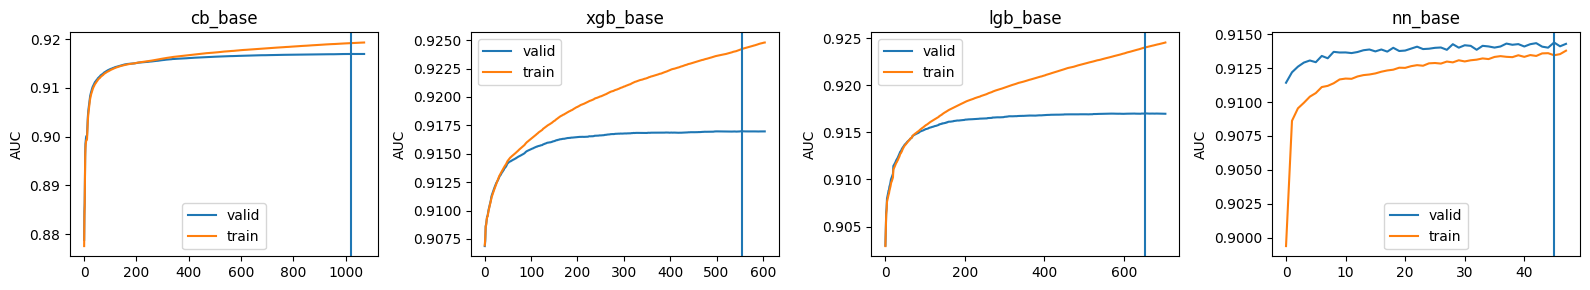

In [69]:
# Learning curves: train vs. validation AUC over boosting iterations.
# The vertical line marks the early stopping point (best validation iteration).
_, axes = plt.subplots(1, 4, figsize=(16, 3))

def plot_eval_result(name, ax, s_train, s_valid):
    sns.lineplot(s_valid, ax=ax, label='valid')
    sns.lineplot(s_train, ax=ax, label='train')
    ax.set_ylabel('AUC')
    ax.axvline(s_valid.argmax())
    ax.set_title(name)
    ax.legend()

d = e_aml.get_collector('cb_evals_results').get_attrs()
eval_result = d['cb_base'][0][0].unstack(level=[1, 2])
plot_eval_result(
    'cb_base', axes[0],
    eval_result[('AUC', 'validation_0')].rename('train'),
    eval_result[('AUC', 'validation_1')].rename('valid')
)
d = e_aml.get_collector('xgb_evals_results').get_attrs()
eval_result = d['xgb_base'][0][0].unstack(level=[1, 2])
plot_eval_result(
    'xgb_base', axes[1],
    eval_result[('auc', 'validation_0')].rename('train'),
    eval_result[('auc', 'validation_1')].rename('valid')
)
d = e_aml.get_collector('lgb_evals_results').get_attrs()
eval_result = d['lgb_base'][0][0].unstack(level=[1, 2])
plot_eval_result(
    'lgb_base', axes[2],
    eval_result[('auc', 'valid_0')].rename('train'),
    eval_result[('auc', 'valid_1')].rename('valid')
)
d = e_aml.get_collector('nn_evals').get_attrs()
eval_result = d['nn_base'][0][0].unstack(level=[1, 2])
plot_eval_result(
    'nn_base', axes[3],
    eval_result[('auc', 'train')].rename('train'),
    eval_result[('auc', 'valid')].rename('valid')
)
plt.tight_layout()
plt.show()

## Feature Engineering Pilot

### Does removing `mt_ratio` hurt?

We added `mt_ratio` (TotalCharges / tenure) before building the pipeline — let's check if the models actually benefited from it by comparing with and without.

In [70]:
e_aml.set_node('xgb_base2', grp='xgb', edges = {'X': [(None, X_bin + X_nom + X_tri + X_num[:-1])]})
e_aml.set_node('lgb_base2', grp='lgb', edges = {'X': [(None, X_bin + X_nom + X_tri + X_num[:-1])]}, params={'categorical_features': ColSelector(col_type = 'category')})
e_aml.set_node('cb_base2', grp='cb', edges = {'X': [(None, X_bin + X_nom + X_tri + X_num[:-1])]}, params={'cat_features': ColSelector(col_type = 'category')})
e_aml.exp()

Experimenting 3 node(s)
Exp 0/1 (0%) > lgb_base2 1/3 (33%) > 1/10000 (0%) valid_0-auc: 0.9028, valid_0-binary_logloss: 0.5130, valid_1-auc: 0.9031, valid_1-binary_logloss: 0.5129Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[514]	valid_0's auc: 0.921835	valid_0's binary_logloss: 0.28879	valid_1's auc: 0.916802	valid_1's binary_logloss: 0.29748
Evaluated only: auc
Exp 1/1 (100%)                                                                                                                                            
Experimentation complete: 3 node(s)


In [71]:
e_aml.get_collector('AUC').get_metrics_agg('xgb.*|lgb.*|cb.*')[0].sort_values('valid', ascending = False)

,valid,train_sub,valid_sub
cb_base2,0.915525,0.919330,0.917035
cb_base,0.915478,0.919196,0.916974
xgb_base,0.915396,0.924214,0.916982
lgb_base,0.915304,0.924048,0.917028
xgb_base2,0.915241,0.922985,0.916720
lgb_base2,0.915226,0.921835,0.916802
cb_base_gpu,0.913448,0.931443,0.914768


In [72]:
e_aml.get_collector('cb_interaction').get_attrs_agg('cb_base2').sort_values(ascending = False).iloc[:20]

feat1             feat2         
TotalCharges      MonthlyCharges    12.938561
                  tenure            12.428400
MonthlyCharges    tenure             9.270028
PaymentMethod     TotalCharges       2.350781
Contract          TotalCharges       2.311913
PaymentMethod     MonthlyCharges     1.926376
Contract          MonthlyCharges     1.907223
                  tenure             1.835189
PaymentMethod     tenure             1.722293
TechSupport       TotalCharges       1.399291
MultipleLines     TotalCharges       1.341633
DeviceProtection  TotalCharges       1.243738
OnlineSecurity    TotalCharges       1.194042
PaymentMethod     MultipleLines      1.188971
InternetService   TotalCharges       1.174696
OnlineBackup      TotalCharges       1.138682
InternetService   tenure             1.089382
StreamingMovies   TotalCharges       1.071903
Contract          MultipleLines      1.037106
MultipleLines     tenure             1.001586
dtype: float64

`mt_ratio` does not provide a meaningful lift — gradient boosting can approximate the ratio internally from `TotalCharges` and `tenure` alone. We'll leave it out for cleaner modeling.

### MonthlyCharges as a Categorical Feature

Given the near-discrete value distribution of `MonthlyCharges`, let's see if treating it as a categorical variable gives a lift.

In [73]:
from mllabs.processor import CatConverter, TypeConverter
from sklearn.preprocessing import TargetEncoder

In [74]:
# TypeConverter converts the float MonthlyCharges column to str dtype.
# CatConverter then casts it to pandas Categorical, which XGBoost can handle natively.
# This two-step approach is needed because XGBoost's enable_categorical requires Categorical dtype,
# and numeric-valued Categoricals can cause errors in some XGBoost versions.
e_aml.set_node('n2s', processor=TypeConverter, grp='pre', edges={'X': [(None, ['MonthlyCharges'])]}, params={'to': str})
e_aml.set_node('s2c', processor=CatConverter, grp='pre', edges={'X': [('n2s', None)]})
e_aml.build()

Building 2 node(s)
Build 1/1 (100%)               
Build complete: 2 node(s)


In [75]:
e_aml.set_node('xgb_base3', grp='xgb', edges = {'X': [(None, X_bin + X_nom + X_tri + ['TotalCharges', 'tenure']), ('s2c', None)]})
e_aml.exp()

Experimenting 1 node(s)
Exp 1/1 (100%)                                                                                     
Experimentation complete: 1 node(s)


In [76]:
# Let me check the pipeline of xgb_base3
Markdown(e_aml.desc_node('xgb_base3', direction='LR'))

```mermaid
graph LR

    DataSource([DataSource])
    style DataSource fill:#fff9c4,stroke:#f57c00,stroke-width:3px

    subgraph node_n2s["pre/n2s"]
        n2s_dummy[ ]
        style n2s_dummy fill:none,stroke:none
    end
    style node_n2s fill:#c8e6c9,stroke:#388e3c,stroke-width:2px

    subgraph node_s2c["pre/s2c"]
        s2c_dummy[ ]
        style s2c_dummy fill:none,stroke:none
    end
    style node_s2c fill:#c8e6c9,stroke:#388e3c,stroke-width:2px

    subgraph node_xgb_base3["clf/xgb/xgb_base3"]
        xgb_base3_dummy[ ]
        style xgb_base3_dummy fill:none,stroke:none
    end
    style node_xgb_base3 fill:#ffcdd2,stroke:#c62828,stroke-width:3px

    DataSource --> node_n2s
    DataSource -->|X,y| node_xgb_base3
    node_n2s --> node_s2c
    node_s2c --> node_xgb_base3
```

**Path from DataSource to 'clf/xgb/xgb_base3' (2 path(s) found)**

### Edges

| Key | Node | Var |
|-----|------|-----|
| X | Data Source | `['Dependents', 'PaperlessBilling', 'Partner', 'PhoneService', 'gender', 'SeniorCitizen', 'PaymentMethod', 'Contract', 'DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'StreamingMovies', 'StreamingTV', 'TechSupport', 'InternetService', 'MultipleLines', 'TotalCharges', 'tenure']` |
| X | pre/s2c | * |
| y | Data Source | `Churn` |

In [77]:
e_aml.get_collector('AUC').get_metrics_agg('xgb.*')[0].sort_values('valid', ascending = False)

,valid,train_sub,valid_sub
xgb_base,0.915396,0.924214,0.916982
xgb_base2,0.915241,0.922985,0.916720
xgb_base3,0.910553,0.922471,0.911894


In [78]:
e_aml.set_node('tgt', grp='pre', processor = TargetEncoder, method = 'fit_transform', edges = {'X': [(None, ['MonthlyCharges'])], 'y': [(None, target)]})
e_aml.set_node('xgb_base4', grp='xgb', edges = {'X': [(None, X_bin + X_nom + X_tri + X_num), ('tgt', None)]}, desc = "MonthlyCharges를 타겟인코딩")
e_aml.build()
e_aml.exp()

Building 1 node(s)
Build 1/1 (100%)               
Build complete: 1 node(s)
Experimenting 1 node(s)
Exp 1/1 (100%)                                                                                     
Experimentation complete: 1 node(s)


In [79]:
e_aml.get_collector('AUC').get_metrics_agg('xgb.*')[0].sort_values('valid', ascending = False)

,valid,train_sub,valid_sub
xgb_base,0.915396,0.924214,0.916982
xgb_base4,0.915246,0.922211,0.916714
xgb_base2,0.915241,0.922985,0.916720
xgb_base3,0.910553,0.922471,0.911894


**My take**: Treating `MonthlyCharges` as categorical is worth exploring in the full modeling phase.
Even a small AUC gain is meaningful at this competition's score range.
However, low-frequency charge values may hurt generalization — `CatOOVFilter` could be used to group rare values before converting to Categorical.

In [80]:
e_aml.set_node('lr_base3', grp='lr', edges = {'X': [(None, X_bin + X_bin2), ('std', None), ('ohe', ohe_drop_first), ('tgt', None)]})
e_aml.exp()

Experimenting 1 node(s)
Exp 1/1 (100%)                    
Experimentation complete: 1 node(s)


In [81]:
e_aml.get_collector('AUC').get_metrics_agg('lr.*')[0].sort_values('valid', ascending = False)

,valid,train_sub,valid_sub
lr_base3,0.907491,0.908100,0.908981
lr_base,0.907455,0.908050,0.908985
lr_base2,0.898323,0.898298,0.900028


---

**Summary and Next Steps**

From this exploration:
- No train/test distribution shift detected — no domain adaptation needed
- `Contract`, `PaymentMethod`, `tenure`, and `MonthlyCharges` are the dominant predictors
- All boosting models cluster in a narrow AUC band — feature engineering will drive further gains
- `MonthlyCharges` as categorical shows early promise; `TargetEncoder` is another option

Full cross-validated modeling, hyperparameter tuning, and ensemble work follow in the next notebook.

In [82]:
# Release all objects (fitted models, cached stage outputs) held by the experimenter.
# Collector data (metrics, importances, etc.) is preserved on disk and can be reloaded later.
e_aml.close_exp()

Finalize 'std'
Finalize 'ohe'
Finalize 'xgb_base'
Finalize 'cb_base'
Finalize 'lgb_base'
Finalize 'nn_base'
Finalize 'lr_base'
Finalize 'dt_base'
Finalize 'cb_base_gpu'
Finalize 'lr_base2'
Finalize 'cb_base2'
Finalize 'lgb_base2'
Finalize 'xgb_base2'
Finalize 'n2s'
Finalize 's2c'
Finalize 'xgb_base3'
Finalize 'tgt'
Finalize 'xgb_base4'
Finalize 'lr_base3'


---

Thank you for reading this notebook!

This is the first public notebook built with **[ml-labs](https://github.com/sunkusun9/ml-labs)**, a personal ML experiment management framework I've been building.
If you found the framework interesting or have any feedback, feel free to check out the repo or leave a comment below — it means a lot.

If this was helpful, an upvote is always appreciated. 🙏